In [13]:
import psi4
import pandas as pd
import os
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from lps_uscf import lps_solver

In [2]:
csv_file = 'open_shell_15atoms_vs_uhf.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f"-> Loaded existing results: {len(df)} rows found.")
else:
    df = pd.DataFrame()
    print("-> No existing file found. Starting fresh.")

-> Loaded existing results: 144 rows found.


In [6]:
psi4.core.set_output_file('output.dat', False)

TP = ['LDA_K_TF', 1.0]
LAMBDA = 1.0
EXC = ['LDA_X', 0.0, 'LDA_C_VWN', 0.0]
FA = [True, 1.0]
DIIS = True
MAX_ITER = 15000
DAMPING = [0.9, 0.9, 0.00009]
# D_guess = [GUESS_A, GUESS_B]
D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

mol = psi4.geometry("""
units bohr
0 3
S
symmetry c1
""")

E, Da, Db, iterations, e_conv, d_conv = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
print('\nFinal SCF energy: %.4f Hartree' % E)
GUESS_A = Da
GUESS_B = Db


Final SCF energy: -270.0144 Hartree


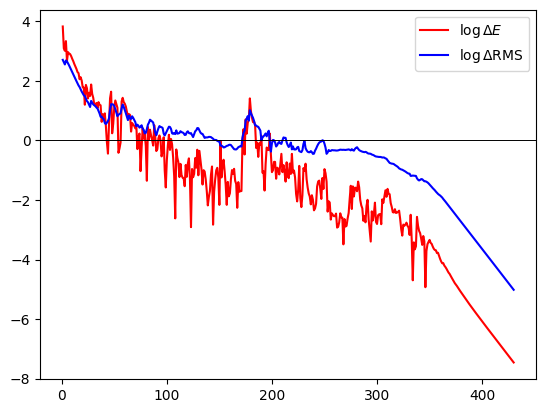

In [22]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_conv, color = 'red', linestyle='-', label='$\\log{\\Delta E}$')
plt.plot(dist, d_conv, color = 'blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()

In [ ]:
psi4.core.set_output_file('output.dat', False)

ATOMS = {
    # Period 3 (Na-Ar)
    # 'Na': {'mult': 2},  # [Ne] 3s1
    # 'Mg': {'mult': 1},  # [Ne] 3s2
    # 'Al': {'mult': 2},  # [Ne] 3s2 3p1
    # 'Si': {'mult': 3},  # [Ne] 3s2 3p2 
    # 'P':  {'mult': 4},  # [Ne] 3s2 3p3 
    # 'S':  {'mult': 3},  # [Ne] 3s2 3p4
    'Cl': {'mult': 2},  # [Ne] 3s2 3p5
    # 'Ar': {'mult': 1},  # [Ne] 3s2 3p6
    # Period 4 (Selected)
    # 'K':  {'mult': 2},  # [Ar] 4s1
    # 'Ca': {'mult': 1},  # [Ar] 4s2
    # 'Cu': {'mult': 2},  # [Ar] 3d10 4s1 
    # 'Zn': {'mult': 1},  # [Ar] 3d10 4s2
    # 'Kr': {'mult': 1},  # [Ar] 3d10 4s2 4p6
}

METHOD = "TF0.333333W PBE"
TP = ['LDA_K_TF', 1.0]
LAMBDA = 0.333333
# EXC = ['LDA_X', 1.0, 'LDA_C_VWN', 0.0]
EXC = ['GGA_X_PBE', 1.0, 'LDA_C_VWN', 0.0]
FA = [False, 1.0]
DIIS = True
MAX_ITER = 10000
DAMPING = [0.99, 0.99, 0.00009]
# D_guess = [GUESS_A, GUESS_B]
D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

for atom in ATOMS:
    
    if not df.empty:
        exists = df[
            (df['Atom'] == atom) & 
            (df['Method'] == METHOD) & 
            (df['Basis'] == psi4.core.get_global_option("BASIS"))
        ]
        if not exists.empty:
            print(f"Skipping {atom} (Already exists for {METHOD}/{psi4.core.get_global_option("BASIS")})")
            continue

    print(f"Calculating {atom} with {METHOD}...")
    MOL = psi4.geometry(f"0 {ATOMS[atom]['mult']}\n {atom}\nsymmetry c1")
    try:
        E, Da, Db, iterations = lps_solver(MAX_ITER,TP,EXC,LAMBDA,MOL,DAMPING,FA,D_guess,DIIS,verbose)
        if iterations >= MAX_ITER:
            print("  !!! SCF failed to converge (Max cycles exceeded).")
        else:
            print(f"Calculated Energy: {E:.4f} Hartree")
            row = {
                "Method": METHOD,
                "Atom": atom,
                "Basis": psi4.core.get_global_option("BASIS"),
                "Grid_Sph": psi4.core.get_global_option("DFT_SPHERICAL_POINTS"),
                "Grid_Rad": psi4.core.get_global_option("DFT_RADIAL_POINTS"),
                "Energy,Ha": round(E, 6),
                "Iterations": iterations,
                "DIIS": DIIS,
                "Damp_Start": DAMPING[0],
                "Damp_End": DAMPING[1],
                "Damp_Cutoff": DAMPING[2]
            }
            
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    
    except Exception as e:
        print(f"  !!! Failed {atom}. Error: {e}")
        continue

In [35]:
df.to_csv(csv_file, index=False)
df

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
0,TFW LDA,Na,UGBS_S,6,1000,-108.912083,284,True,0.90,0.90,0.00009
1,TFW LDA,Mg,UGBS_S,6,1000,-135.553609,237,True,0.90,0.90,0.00009
2,TFW LDA,Al,UGBS_S,6,1000,-165.669941,387,True,0.90,0.90,0.00009
3,TFW LDA,Si,UGBS_S,6,1000,-199.392286,517,True,0.90,0.90,0.00009
4,TFW LDA,P,UGBS_S,6,1000,-236.833553,342,True,0.90,0.90,0.00009
...,...,...,...,...,...,...,...,...,...,...,...
139,TF0.111111W LDA,Na,UGBS_S,6,1000,-175.220390,4870,True,0.99,0.99,0.00003
140,TF0.111111W LDA,Mg,UGBS_S,6,1000,-215.265035,4402,True,0.99,0.99,0.00003
141,TF0.111111W LDA,Al,UGBS_S,6,1000,-260.117429,14370,True,0.99,0.99,0.00003
142,TF0.111111W LDA,Si,UGBS_S,6,1000,-309.909768,8732,True,0.99,0.90,0.00005


In [ ]:
## TF0.111111W PBE for O and F used TF0.111111W FA densities of O and F as initial guesses
## TF0.111111W FA for Si, Kr used TF0.166666W FA initial guess
## TF0.2W FA for Cl used TF0.333333W FA initial guess
## TF0.166666W FA for Cl used TF0.2W FA initial guess
## TF0.111111W LDA for Si, P used TF0.111111W LDA density of a previous atom

In [7]:
df[(df['Method'] == 'TFW FA') & (df['Atom'] == 'S')]

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
29,TFW FA,S,UGBS_S,6,1000,-270.014427,430,True,0.9,0.9,0.00009


In [10]:
atom_order = ['Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Zn', 'Kr']
energy_table = df.pivot(index='Atom', columns='Method', values='Energy,Ha')
energy_table = energy_table.reindex(atom_order)
energy_table

Method,TF0.111111W FA,TF0.111111W LDA,TF0.166666W FA,TF0.166666W LDA,TF0.166666W PBE,TF0.2W FA,TF0.2W LDA,TF0.2W PBE,TF0.333333W FA,TF0.333333W LDA,TF0.333333W PBE,TFW FA,TFW LDA,TFW PBE
Atom,,,,,,,,,,,,,,
Na,-169.876758,-175.220390,NaN,-166.247018,-167.439022,-156.665459,-161.732209,-162.884191,-142.690045,-147.423156,-148.454126,-105.226002,-108.912083,-109.651463
Mg,-208.826727,-215.265035,-198.305386,-204.540681,-205.864548,-193.013833,-199.138984,-200.419079,-176.244867,-181.989422,-183.137203,-131.025067,-135.553609,-136.382297
Al,-252.536872,-260.117429,-240.123724,-247.478726,NaN,-233.874058,-241.106354,NaN,-214.036249,-220.842857,-222.107058,-160.241930,-165.669941,-166.588302
Si,-301.135691,-309.909768,-286.667497,NaN,-296.779753,-279.375910,-287.767440,-289.302316,-256.195211,-264.117075,-265.498027,-193.008025,-199.392286,-200.400917
P,-354.731372,-364.755320,-338.045378,-347.799950,-349.517759,-329.628312,-339.235807,-340.899147,-302.831533,-311.925851,-313.424434,-229.434658,-236.833553,-237.933265
S,-413.577377,NaN,-394.530559,NaN,NaN,-384.915848,NaN,-397.768400,-354.272546,-364.758190,-366.381630,-270.014427,-278.601238,-279.798321
Cl,NaN,NaN,-456.106275,NaN,NaN,-445.209435,-457.757749,NaN,-410.442846,-422.371240,NaN,-314.492584,-324.324636,-325.619280
Ar,-547.190764,NaN,-522.928926,-537.208760,-539.346529,-510.665243,-524.754841,-526.826944,-471.497581,-484.916246,-486.789800,-363.016580,-374.146432,-375.538832
K,NaN,NaN,-595.127590,NaN,NaN,-581.412138,-597.089205,NaN,-537.564831,-552.520707,-554.518805,-415.710015,-428.188235,-429.678591


In [ ]:
ATOMS = {
    'He':  {'mult': 1}, 
    'Be': {'mult': 1},
    'Ne': {'mult': 1}, 
    'Mg': {'mult': 1},
    'Ar':  {'mult': 1}, 
    'Ca':  {'mult': 1},
    'Zn':  {'mult': 1}, 
    'Kr':  {'mult': 1}
}
psi4.core.set_output_file('output.dat', False)
psi4.set_options({'basis': 'UGBS',
                  'scf_type': 'PK'})
rhf_energies = {}
rhf_homos = {}
for atom in ATOMS:
    MOL = psi4.geometry(f"0 {ATOMS[atom]['mult']}\n {atom}\nsymmetry c1")
    E, wfn = psi4.energy('SCF', return_wfn=True)
    rhf_energies[atom] = round(E, 6)
    print(f"RHF/UGBS {atom} Energy: {E:.4f} Hartree")

RHF/UGBS He Energy: -2.8617 Hartree, IP: -0.9180
RHF/UGBS Be Energy: -14.5730 Hartree, IP: -0.3093
RHF/UGBS Ne Energy: -128.5471 Hartree, IP: -0.8504
RHF/UGBS Mg Energy: -199.6146 Hartree, IP: -0.2530
RHF/UGBS Ar Energy: -526.8175 Hartree, IP: -0.5910
RHF/UGBS Ca Energy: -676.7582 Hartree, IP: -0.1955
RHF/UGBS Zn Energy: -1777.8481 Hartree, IP: -0.2925
RHF/UGBS Kr Energy: -2752.0549 Hartree, IP: -0.5242


In [26]:
atom_order = ['He', 'Be', 'Ne', 'Mg', 'Ar', 'Ca', 'Zn', 'Kr']
energy_table = df.pivot(index='Atom', columns='Method', values='Energy,Ha')
energy_table = energy_table.reindex(atom_order)
energy_table['RHF/UGBS'] = pd.Series(rhf_energies)
new_order = ['TFD0.166666W', 'TF0.166666W PBEx', 'TF0.166666W FA', 'RHF/UGBS']
energy_table = energy_table[new_order]

In [28]:
reference = energy_table['RHF/UGBS']

res = {}
for method, energies in energy_table.items():
    if method == 'RHF/UGBS': 
        continue 
    
    mae  = (energies - reference).abs().mean()
    rmae = (((energies - reference).abs()) / reference * -100).mean()
    res[method] = round(mae, 2), round(rmae, 2)

mae_row  = {method: values[0] for method, values in res.items()}
rmae_row = {method: values[1] for method, values in res.items()}
stats_df = pd.DataFrame([mae_row, rmae_row], index=['MAE(Ha)', 'rMAE(%)'])
energy_table = pd.concat([energy_table, stats_df], sort=False)

In [29]:
display(energy_table)

,TFD0.166666W,TF0.166666W PBEx,TF0.166666W FA,RHF/UGBS
He,-2.951247,-3.097069,-3.019526,-2.861680
Be,-15.040391,-15.388877,-14.660508,-14.573023
Ne,-132.508856,-133.573716,-128.291707,-128.547083
Mg,-204.540690,-205.864549,-198.305386,-199.614621
Ar,-537.208760,-539.346529,-522.928926,-526.817486
Ca,-690.396266,-692.814969,-672.808485,-676.758154
Zn,-1812.192490,-1816.067937,-1773.727670,-1777.848060
Kr,-2795.914635,-2800.696590,-2741.665221,-2752.054860
MAE(Ha),13.960000,15.970000,3.020000,NaN
rMAE(%),2.420000,3.690000,1.110000,NaN
